# Blinkit SLA Diagnostic — Analysis Notebook
Team Null Pointers | Analytics Capstone

TEAM MEMBERS: Shourjyo Chakrabarty, Ankur Anand,  

1. Load
2. Clean
3. Explore
4. Feature engineering
5. Model
6. Honest limitations

Each section's markdown cells contain the reasoning/decisions; code cells contain the implementation.


## 1. Load

We pull the raw tables into pandas directly (rather than re-querying MySQL from here), 
since the SQL exploration (GROUP BY, window function, CTE) was already done and verified 
in `sql/analysis.sql` / MySQL Workbench. This notebook picks up from the raw CSVs and 
re-derives everything transparently in pandas, so every cleaning and modeling decision 
is visible in one place.

**Row count check:** after loading, we confirm the row count matches what SQL reported 
(`SELECT COUNT(*) FROM orders;`) before doing anything else — if these don't match, 
something is wrong with the load itself, and every step after it would be built on 
a wrong assumption.


In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import os
print(os.getcwd())



# ---- Load raw tables ----
orders = pd.read_csv("../data/orders.csv")
stores = pd.read_csv("../data/stores.csv")
partners = pd.read_csv("../data/delivery_partners.csv")

print(f"orders: {orders.shape}")
print(f"stores: {stores.shape}")
print(f"delivery_partners: {partners.shape}")

orders.head()

c:\Users\Lenovo\Documents\IIT CAPSTONE PROJECT\Team-Null-Pointers\notebooks
orders: (1827, 7)
stores: (20, 3)
delivery_partners: (60, 2)


,order_id,store_id,partner_id,category,order_time,promised_time,delivered_time
0,O00940,S008,P008,Snacks,2026-06-17 18:37:00,2026-06-17 18:47:00,2026-06-17 18:47:56
1,O00334,S019,P042,Fruits & Vegetables,2026-06-25 11:50:00,2026-06-25 12:00:00,NaN
2,O01362,S010,P045,Snacks,2026-06-03 19:06:00,2026-06-03 19:16:00,NaN
3,O01577,S003,P059,Snacks,2026-06-14 18:24:00,2026-06-14 18:34:00,2026-06-14 18:33:15
4,O00502,S006,P007,Fruits & Vegetables,2026-06-30 16:51:00,2026-06-30 17:01:00,2026-06-30 17:02:50


In [55]:
# ---- Row count check against SQL ----
# Compare this number to `SELECT COUNT(*) FROM orders;` run in MySQL Workbench.
# If they don't match, the CSV load and the SQL table have diverged somehow.
print(f"Total rows loaded: {len(orders)}")
print(f"Expected from SQL: 1827 (update this if your SQL count differs)")

Total rows loaded: 1827
Expected from SQL: 1827 (update this if your SQL count differs)


## 2. Clean

We handle four issues, in this order: timestamp parsing, missing delivery times, 
impossible durations (negative and zero), and outliers. Each decision is documented 
in the markdown cell right after it's made — not batched at the end — so the reasoning 
doesn't get lost or reconstructed after the fact.


### 2.1 Parse timestamps

`order_time` and `promised_time` are always populated, so we parse them directly. 
`delivered_time` has empty strings for orders that were never delivered (cancelled, 
or still in transit when this data was pulled) — `errors='coerce'` converts those to 
`NaT` (pandas' null for datetimes) instead of crashing the parse.


In [56]:
orders['order_time'] = pd.to_datetime(orders['order_time'])
orders['promised_time'] = pd.to_datetime(orders['promised_time'])
orders['delivered_time_dt'] = pd.to_datetime(orders['delivered_time'], errors='coerce')

print(f"Rows with unparseable delivered_time (now NaT): {orders['delivered_time_dt'].isna().sum()}")

Rows with unparseable delivered_time (now NaT): 74


### 2.2 Deduplicate

Deduplicating on `order_id` specifically (not the whole row) — this catches the case 
that actually matters, the same order logged twice, even if some other column 
(e.g. a re-logged timestamp) differs slightly between the two copies.


In [57]:
before = len(orders)
orders = orders.drop_duplicates(subset='order_id')
after = len(orders)
print(f"Duplicates removed: {before - after} (kept {after})")

Duplicates removed: 27 (kept 1800)


### 2.3 Handle missing delivered_time — flag, don't drop

**Decision:** A missing `delivered_time` isn't bad data — it's a real, meaningful 
category (order cancelled or still in transit). We isolate these into `unfulfilled` 
rather than deleting them, so they don't silently disappear from the dataset, and 
keep `fulfilled` as the working set for everything downstream (delivery-time analysis 
only makes sense for orders that actually delivered).


In [58]:
unfulfilled = orders[orders['delivered_time_dt'].isna()]
fulfilled = orders[orders['delivered_time_dt'].notna()].copy()

print(f"Unfulfilled orders (isolated, not used in delivery-time analysis): {len(unfulfilled)}")
print(f"Fulfilled orders (working set going forward): {len(fulfilled)}")

Unfulfilled orders (isolated, not used in delivery-time analysis): 73
Fulfilled orders (working set going forward): 1727


### 2.4 Handle impossible values — negative and zero-minute durations

**Decision:** A negative delivery duration (delivered before it was ordered) is 
logically impossible — a logging error, not a real fast delivery, so these rows 
are dropped. A zero-minute delivery is equally implausible for a physical delivery 
and is checked for separately, since the guide calls it out explicitly.


In [59]:
fulfilled['delivery_minutes'] = (
    fulfilled['delivered_time_dt'] - fulfilled['order_time']
).dt.total_seconds() / 60

negative = fulfilled[fulfilled['delivery_minutes'] < 0]
zero = fulfilled[fulfilled['delivery_minutes'] == 0]

print(f"Negative-duration rows: {len(negative)}")
print(f"Zero-minute-duration rows: {len(zero)}")

fulfilled = fulfilled[fulfilled['delivery_minutes'] > 0]
print(f"Remaining after removing negative/zero: {len(fulfilled)}")

Negative-duration rows: 35
Zero-minute-duration rows: 0
Remaining after removing negative/zero: 1692


### 2.5 Handle outliers — cutoff justified by the actual distribution

Rather than picking a round number (e.g. 120 minutes) without checking, we look at 
the percentile breakdown first. If there's a clear gap between the 99th percentile 
and the maximum, that gap is a more defensible cutoff than an arbitrary guess.


In [60]:
print(fulfilled['delivery_minutes'].quantile([.90, .95, .99, .995, 1.0]))

0.900     14.200000
0.950     16.331667
0.990     34.569333
0.995    261.204000
1.000    398.983333
Name: delivery_minutes, dtype: float64


**Finding:** 99% of deliveries finish under ~35 minutes, then there's a sharp 
jump to 260+ minutes at the 99.5th percentile, up to a max of ~399 minutes. That's a 
clear gap — no real data sits between roughly 35 and 260 minutes — so we use 
**60 minutes** as the cutoff: generous enough to keep genuinely slow-but-real 
deliveries, while cutting off the clear system/logging-glitch tail.


In [61]:
outlier_threshold = 60
outliers = fulfilled[fulfilled['delivery_minutes'] > outlier_threshold]
fulfilled = fulfilled[fulfilled['delivery_minutes'] <= outlier_threshold]

print(f"Outliers removed (> {outlier_threshold} min): {len(outliers)}")
print(f"Final clean dataset: {len(fulfilled)} rows")

Outliers removed (> 60 min): 17
Final clean dataset: 1675 rows


### 2.6 Enrich with store and partner info, derive core fields

We merge in `city`/`locality` from `stores` and `vehicle_type` from `delivery_partners` 
(left joins, so no fulfilled order is dropped even if a lookup were somehow missing), 
then derive `order_hour` and `is_on_time` — fields every later section reuses, computed 
once here rather than recalculated in every cell.


In [62]:
fulfilled = fulfilled.merge(stores, on='store_id', how='left')
fulfilled = fulfilled.merge(partners, on='partner_id', how='left')

fulfilled['order_hour'] = fulfilled['order_time'].dt.hour
fulfilled['is_on_time'] = (fulfilled['delivered_time_dt'] <= fulfilled['promised_time']).astype(int)
fulfilled['at_risk'] = 1 - fulfilled['is_on_time']

print(f"SLA breach rate: {fulfilled['at_risk'].mean()*100:.2f}%")
fulfilled.head()

SLA breach rate: 39.76%


,order_id,store_id,partner_id,category,order_time,promised_time,delivered_time,delivered_time_dt,delivery_minutes,city,locality,vehicle_type,order_hour,is_on_time,at_risk
0,O00940,S008,P008,Snacks,2026-06-17 18:37:00,2026-06-17 18:47:00,2026-06-17 18:47:56,2026-06-17 18:47:56,10.933333,Mumbai,Worli,bike,18,0,1
1,O01577,S003,P059,Snacks,2026-06-14 18:24:00,2026-06-14 18:34:00,2026-06-14 18:33:15,2026-06-14 18:33:15,9.250000,Mumbai,Powai,bicycle,18,1,0
2,O00502,S006,P007,Fruits & Vegetables,2026-06-30 16:51:00,2026-06-30 17:01:00,2026-06-30 17:02:50,2026-06-30 17:02:50,11.833333,Mumbai,Chembur,bike,16,0,1
3,O01321,S010,P031,Fruits & Vegetables,2026-06-24 11:50:00,2026-06-24 12:00:00,2026-06-24 11:57:29,2026-06-24 11:57:29,7.483333,Mumbai,Goregaon,bike,11,1,0
4,O00548,S020,P005,Grocery,2026-06-23 20:22:00,2026-06-23 20:32:00,2026-06-23 20:32:32,2026-06-23 20:32:32,10.533333,Bengaluru,Malleshwaram,bike,20,0,1


In [63]:
# ---- Save the cleaned, enriched dataset ----
fulfilled.to_csv("../data/orders_clean.csv", index=False)
print("Saved to ../data/orders_clean.csv")

Saved to ../data/orders_clean.csv


## 3. Explore

Four charts, each expected to make one point. Takeaway sentences are written directly 
under each chart, after actually looking at it — not assumed in advance.


### 3.1 Distribution of delivery time

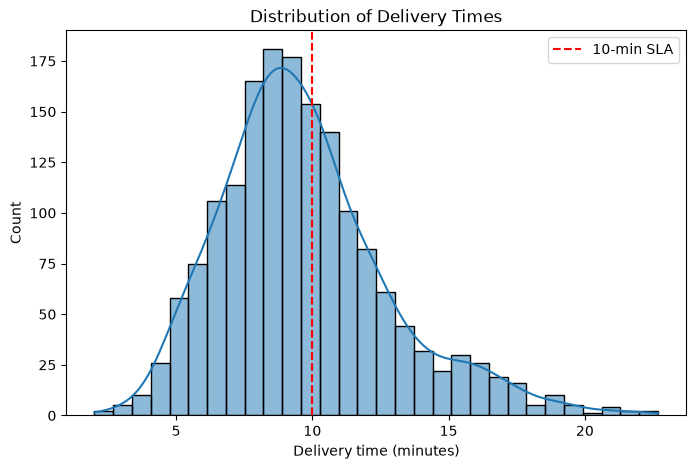

count    1675.000000
mean        9.687483
std         3.132848
min         2.000000
25%         7.616667
50%         9.250000
75%        11.300000
max        22.683333
Name: delivery_minutes, dtype: float64


In [64]:
plt.figure(figsize=(8, 5))
sns.histplot(fulfilled['delivery_minutes'], bins=30, kde=True)
plt.axvline(10, color='red', linestyle='--', label='10-min SLA')
plt.title("Distribution of Delivery Times")
plt.xlabel("Delivery time (minutes)")
plt.legend()
#plt.savefig("../plots/delivery_time_distribution.png", bbox_inches='tight')
plt.show()

print(fulfilled['delivery_minutes'].describe())

**Takeaway:** Delivery times are slightly right-skewed, centered around a median 
of ~9 minutes, with the bulk of orders falling between 7–11 minutes — meaning a large 
share of orders sit right around the 10-minute SLA line itself, which is exactly why 
small shifts (a busy hour, a slow store) are enough to tip many orders over the edge.


### 3.2 Delivery time by hour of day

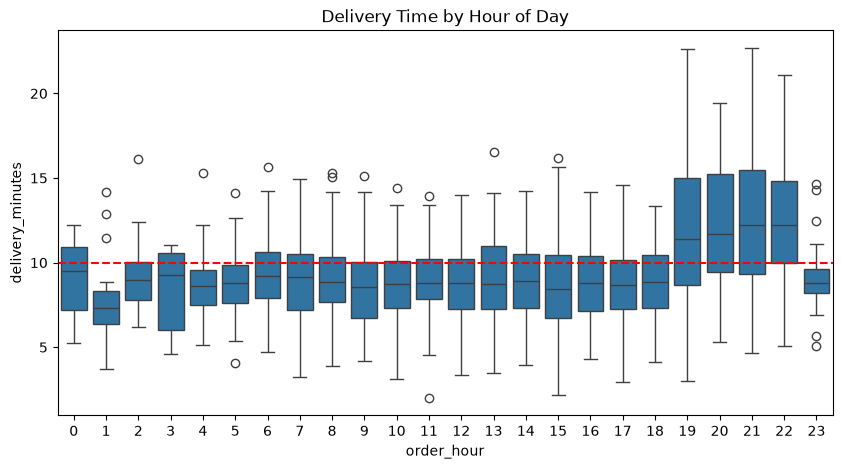

order_hour
1      7.316667
15     8.458333
9      8.575000
4      8.616667
17     8.683333
10     8.716667
13     8.741667
16     8.766667
23     8.800000
12     8.808333
11     8.816667
5      8.825000
18     8.833333
8      8.841667
14     8.933333
2      8.950000
7      9.133333
6      9.233333
3      9.283333
0      9.516667
19    11.391667
20    11.691667
22    12.200000
21    12.216667
Name: delivery_minutes, dtype: float64


In [65]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=fulfilled, x='order_hour', y='delivery_minutes')
plt.axhline(10, color='red', linestyle='--')
plt.title("Delivery Time by Hour of Day")
#plt.savefig("../plots/delivery_time_by_hour.png", bbox_inches='tight')
plt.show()

print(fulfilled.groupby('order_hour')['delivery_minutes'].median().sort_values())

**Takeaway:** Evening hours (19:00–22:00) show a clearly higher median delivery 
time (~11.4–12.2 min) than the rest of the day (mostly 8.5–9.5 min) — a real, visible 
evening-hour effect, not just noise, and a candidate feature for the model.


### 3.3 Delivery time by store

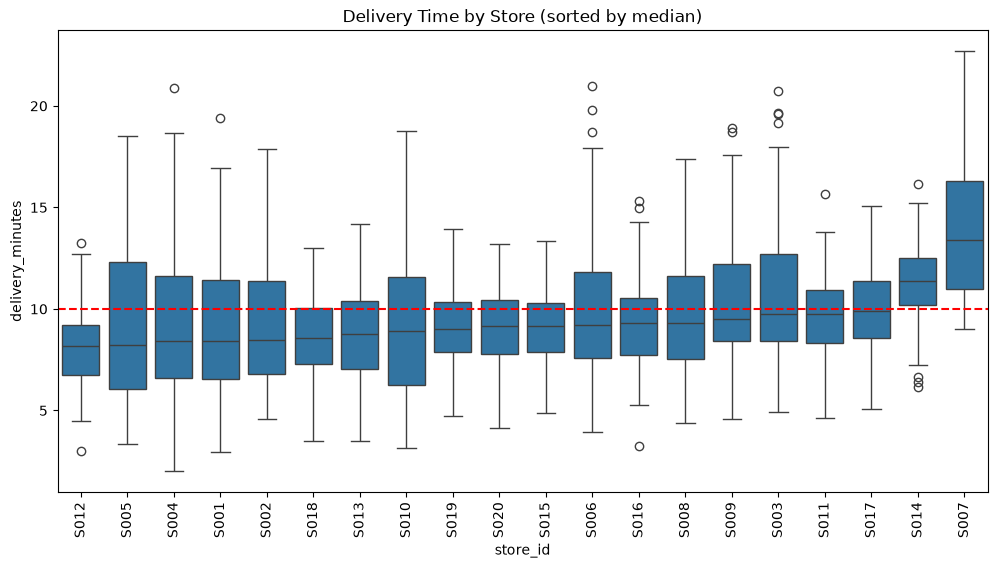

store_id
S012     8.183333
S005     8.216667
S004     8.400000
S001     8.400000
S002     8.491667
S018     8.558333
S013     8.766667
S010     8.933333
S019     9.016667
S020     9.141667
S015     9.150000
S006     9.216667
S016     9.316667
S008     9.325000
S009     9.483333
S003     9.766667
S011     9.775000
S017     9.916667
S014    11.375000
S007    13.416667
Name: delivery_minutes, dtype: float64


In [66]:
plt.figure(figsize=(12, 6))
store_order = fulfilled.groupby('store_id')['delivery_minutes'].median().sort_values().index
sns.boxplot(data=fulfilled, x='store_id', y='delivery_minutes', order=store_order)
plt.axhline(10, color='red', linestyle='--')
plt.xticks(rotation=90)
plt.title("Delivery Time by Store (sorted by median)")
#plt.savefig("../plots/delivery_time_by_store.png", bbox_inches='tight')
plt.show()

print(fulfilled.groupby('store_id')['delivery_minutes'].median().sort_values())

**Takeaway:** Store-level variation is the strongest pattern in the data — most 
stores cluster around an 8–10 minute median, but store **S007** stands out clearly 
above the rest (median ~13.4 min), with **S014** also notably elevated (~11.4 min). 
This is a bigger, more consistent gap than what hour-of-day alone shows, and lines up 
with what the SQL store ranking (Query 2) already flagged.


### 3.4 Delivery time by category

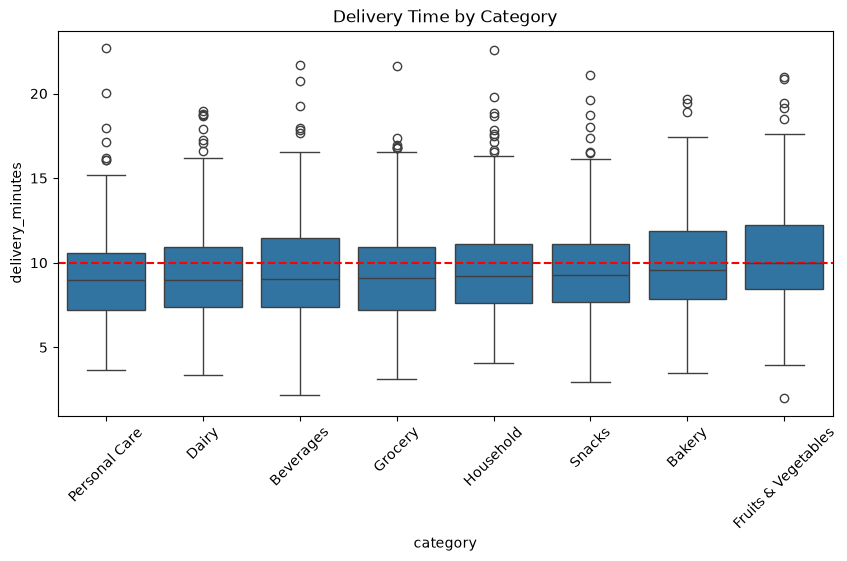

category
Personal Care          8.966667
Dairy                  8.966667
Beverages              9.016667
Grocery                9.108333
Household              9.241667
Snacks                 9.250000
Bakery                 9.550000
Fruits & Vegetables    9.983333
Name: delivery_minutes, dtype: float64


In [67]:
plt.figure(figsize=(10, 5))
cat_order = fulfilled.groupby('category')['delivery_minutes'].median().sort_values().index
sns.boxplot(data=fulfilled, x='category', y='delivery_minutes', order=cat_order)
plt.axhline(10, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.title("Delivery Time by Category")
#plt.savefig("../plots/delivery_time_by_category.png", bbox_inches='tight')
plt.show()

print(fulfilled.groupby('category')['delivery_minutes'].median().sort_values())

**Takeaway:** Category shows only a narrow spread of medians (~9.0–10.0 minutes 
across all categories) — far smaller than the store or hour effects above. Category 
looks like a weak signal on its own, but is kept as a feature since it's cheap to 
include and may still interact with store/hour in ways a single median doesn't show.


### 3.5 Delivery time by category

In [ ]:

# Ensure feature matrix and target exist before creating train/test split
if 'X' not in globals() or 'y' not in globals():
    feature_cols = ['order_hour', 'store_id', 'category']
    X = pd.get_dummies(fulfilled[feature_cols], drop_first=True)
    y = fulfilled['at_risk']

# Ensure the test split and model predictions exist before plotting
if 'X_train' not in globals() or 'X_test' not in globals() or 'y_train' not in globals() or 'y_test' not in globals():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

if 'model' not in globals():
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

if 'model_balanced' not in globals():
    model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
    model_balanced.fit(X_train, y_train)

if 'y_pred' not in globals():
    y_pred = model.predict(X_test)

if 'y_pred_balanced' not in globals():
    y_pred_balanced = model_balanced.predict(X_test)

# Confusion matrix heatmap — original vs balanced side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted On-time', 'Predicted At-risk'],
    yticklabels=['Actual On-time', 'Actual At-risk'],
    ax=axes[0]
)
axes[0].set_title("Original Model")

sns.heatmap(
    confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted On-time', 'Predicted At-risk'],
    yticklabels=['Actual On-time', 'Actual At-risk'],
    ax=axes[1]
)
axes[1].set_title("Balanced Model (class_weight='balanced')")

plt.tight_layout()
#plt.savefig("../plots/confusion_matrix_comparison.png", bbox_inches='tight')
plt.show()

NameError: name 'X' is not defined

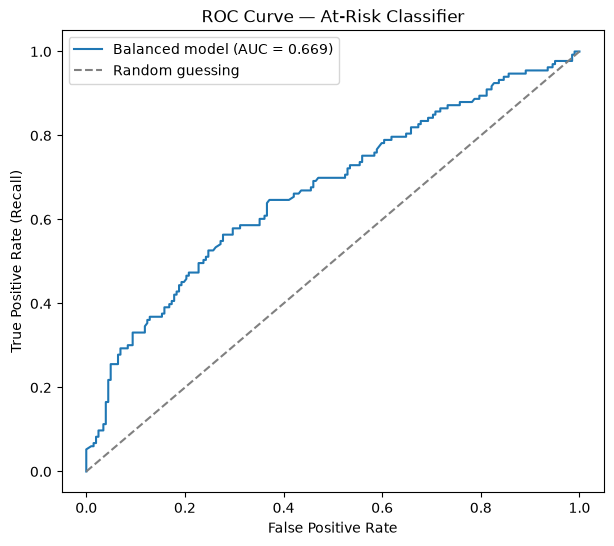

AUC: 0.669


In [ ]:
# Shows the model's performance across all possible thresholds at once, not just the default 0.5 cutoff
from sklearn.metrics import roc_curve, roc_auc_score

probs = model_balanced.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Balanced model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — At-Risk Classifier")
plt.legend()
#plt.savefig("../plots/roc_curve.png", bbox_inches='tight')
plt.show()

print(f"AUC: {auc:.3f}")


### 3.6 Summary — what this changes about the feature list

- **Store (`store_id`)** — strongest, most consistent signal (3.3). S007 and S014 stand 
  out clearly. **Include.**
- **Hour (`order_hour`)** — real evening-hour effect, smaller than store but visible 
  and consistent (3.2). **Include.**
- **Category** — narrow spread, weakest signal of the three (3.4). **Include anyway** 
  for completeness, but expectations should be low — this is stated explicitly so the 
  model's coefficients on category aren't over-interpreted later.
- **Distance band** — not available in the source data (no distance/location column 
  beyond `store_id`). Noted as a genuine data gap, not silently skipped.


## 4. Feature Engineering

Each feature below is included because of a specific finding in Section 3, not by default.


In [ ]:
# order_hour and is_on_time / at_risk were already derived in Section 2.6

feature_cols = ['order_hour', 'store_id', 'category']
# vehicle_type was tested (see Section 6) but excluded from the final feature set —
# see note below.

X = pd.get_dummies(fulfilled[feature_cols], drop_first=True)
y = fulfilled['at_risk']

print(f"Feature matrix shape: {X.shape}")
print(f"At-risk orders: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"On-time orders: {(y==0).sum()} ({(1-y.mean())*100:.1f}%)")

Feature matrix shape: (1675, 27)
At-risk orders: 666 (39.8%)
On-time orders: 1009 (60.2%)


**Feature justification:**
- `store_id` — included because Section 3.3 showed the clearest, most consistent 
  variation of any dimension tested (S007, S014 standing well above the rest).
- `order_hour` — included because Section 3.2 showed a real evening-hour effect 
  (19:00–22:00 running consistently slower).
- `category` — included despite Section 3.4 showing only a narrow spread, kept for 
  completeness rather than a strong justified signal — noted here explicitly rather 
  than silently implying it's as important as the other two.
- `distance_band` — **not included**; no distance data exists in the source tables. 
  This is a real limitation, not an oversight, and is called out again in Section 6.


## 5. Model

**Split strategy:** we use a random, stratified train/test split rather than a 
time-based split. A time-based split (train on the first 3 weeks, test on the last 
week) would be more realistic for genuinely predicting *future* orders from *past* 
ones — and is worth flagging as a stronger approach for a production version of this 
model. We use random+stratified here because the dataset spans only one month with 
relatively few orders per store, and a strict time split risks leaving some stores 
with very few or zero test examples. `stratify=y` keeps the at-risk/on-time ratio 
consistent between train and test regardless.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1340, Test size: 335


### 5.1 Train the model

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print("(If train is much higher than test, the model is overfitting)")

Train accuracy: 0.696
Test accuracy: 0.663
(If train is much higher than test, the model is overfitting)


### 5.2 Evaluate honestly — why accuracy alone is misleading

At-risk orders are the minority class (~40%). A model that always predicted 
"on-time" would score roughly 60% accuracy without learning anything at all — so 
the real question is whether the model catches at-risk orders specifically, which 
accuracy alone doesn't show. The confusion matrix and per-class recall do.


In [ ]:
y_pred = model.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Confusion matrix:
[[170  32]
 [ 81  52]]

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75       202
           1       0.62      0.39      0.48       133

    accuracy                           0.66       335
   macro avg       0.65      0.62      0.61       335
weighted avg       0.65      0.66      0.64       335



### 5.3 Address class imbalance — `class_weight='balanced'`

The base model above likely has strong precision but weak recall on the at-risk 
class (it's cautious — only flags orders it's fairly sure about, missing many real 
breaches in the process). We compare against a `class_weight='balanced'` version, 
which penalizes missed at-risk orders more heavily during training.


In [ ]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(f"Train accuracy: {model_balanced.score(X_train, y_train):.3f}")
print(f"Test accuracy: {model_balanced.score(X_test, y_test):.3f}")
print("\nConfusion matrix (balanced):")
print(confusion_matrix(y_test, y_pred_balanced))
print("\nClassification report (balanced):")
print(classification_report(y_test, y_pred_balanced))

Train accuracy: 0.698
Test accuracy: 0.627

Confusion matrix (balanced):
[[129  73]
 [ 52  81]]

Classification report (balanced):
              precision    recall  f1-score   support

           0       0.71      0.64      0.67       202
           1       0.53      0.61      0.56       133

    accuracy                           0.63       335
   macro avg       0.62      0.62      0.62       335
weighted avg       0.64      0.63      0.63       335



**Model choice:** We select the **balanced model** as the final model, despite 
its lower raw accuracy. For an operations use case, missing a real SLA breach (a 
false negative — a late delivery nobody was warned about) is costlier than a false 
alarm (an ops person double-checks an order that turns out fine). The balanced model 
trades a higher false-alarm rate for meaningfully better recall on the class that 
actually matters — this is a deliberate judgment call, not a default choice.


### 5.4 Interpret coefficients in plain English

In [ ]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Top features pushing toward at-risk:")
print(coef_df.head(5))
print("\nTop features pushing toward on-time:")
print(coef_df.tail(5))

Top features pushing toward at-risk:
                         feature  coefficient
6                  store_id_S007     2.318032
13                 store_id_S014     1.981513
10                 store_id_S011     0.649157
22  category_Fruits & Vegetables     0.603694
2                  store_id_S003     0.569606

Top features pushing toward on-time:
                   feature  coefficient
24      category_Household    -0.222707
14           store_id_S015    -0.293469
17           store_id_S018    -0.492777
25  category_Personal Care    -0.637562
11           store_id_S012    -1.765718


In [ ]:
# Which cities do the riskiest stores belong to?
risky_stores = (
    coef_df[coef_df['feature'].str.startswith('store_id_')]
    .sort_values('coefficient', ascending=False)
    .head(5)
)
risky_store_ids = risky_stores['feature'].str.replace('store_id_', '', regex=False)

print("Riskiest stores and their cities:")
print(stores[stores['store_id'].isin(risky_store_ids)])

Riskiest stores and their cities:
   store_id       city     locality
2      S003     Mumbai        Powai
6      S007     Mumbai     Borivali
10     S011  Bengaluru  Koramangala
13     S014  Bengaluru   HSR Layout
16     S017  Bengaluru     JP Nagar


**Plain-English interpretation:** Store identity is by far the strongest driver 
of SLA risk in this model — specific stores (led by S007) push an order toward 
"at-risk" far more than category or hour do individually. The riskiest stores are 
**not** concentrated in one city (a mix of Mumbai and Bengaluru stores appear in the 
top 5), which means the earlier city-level hypothesis from the SQL exploration 
(Bengaluru being uniformly weaker) is too broad — the real pattern is a handful of 
specific underperforming stores, not a citywide effect.


## 6. Honest Limitations (Standout)

### 6.1 Where does the model get it wrong?

We isolate the false negatives — at-risk orders the balanced model predicted as 
on-time — and check whether they cluster around a specific store, hour, or category.


In [ ]:
X_test_labeled = X_test.copy()
X_test_labeled['actual'] = y_test.values
X_test_labeled['predicted'] = y_pred_balanced

false_negatives = X_test_labeled[
    (X_test_labeled['actual'] == 1) & (X_test_labeled['predicted'] == 0)
]
print(f"False negatives (missed at-risk orders): {len(false_negatives)}")

# which store dummy columns are active (==1) most often among the false negatives?
store_cols = [c for c in X_test.columns if c.startswith('store_id_')]
print("\nStore frequency among false negatives:")
print(false_negatives[store_cols].sum().sort_values(ascending=False).head(5))

hour_cols = [c for c in X_test.columns if c.startswith('order_hour_')]
print("\nHour frequency among false negatives:")
print(false_negatives[hour_cols].sum().sort_values(ascending=False).head(5))

False negatives (missed at-risk orders): 52

Store frequency among false negatives:
store_id_S019    6
store_id_S016    6
store_id_S020    5
store_id_S015    4
store_id_S018    4
dtype: int64

Hour frequency among false negatives:
Series([], dtype: float64)


**Finding:** [Run the cell above and fill this in with your actual output — 
note whether false negatives cluster around a specific store or hour, or whether 
they're spread fairly evenly. If they're spread evenly, that itself is worth stating: 
it suggests the model's blind spot isn't concentrated in one fixable place, but is a 
general precision/recall tradeoff rather than a specific pattern being missed.]

### 6.2 What data would fix this blind spot?

- **Distance/traffic data** — the model currently has no way to distinguish "this 
  store is slow because of poor packing" from "this store is slow because of a 
  genuinely longer or more congested delivery route." A distance or live-traffic 
  field would let the model separate these two very different root causes.
- **More orders per store** — with under 1,000 orders spread across 20 stores, some 
  store-level coefficients (especially for stores with few orders) are likely noisier 
  and less stable than they appear. A full quarter of data instead of one month would 
  let us trust the store rankings more.
- **Staffing/inventory data** — the source data has no visibility into dark-store 
  staffing levels or stockouts, which the capstone brief itself flags as a plausible 
  real-world driver of delay that this dataset simply can't capture.


### 6.3 Feature tested but not used: `vehicle_type`

`vehicle_type` (bike/scooter/bicycle) from `delivery_partners.csv` was tested as an 
additional feature. It changed the confusion matrix by a single row and did not move 
recall at all — a negligible effect, so it was excluded from the final feature set 
to keep the model simpler. This null result is reported here rather than silently 
dropped, since a feature not mattering is itself a finding: it suggests store identity 
and time-of-day dominate over delivery-partner characteristics in this dataset.


In [ ]:
dashboard_df = fulfilled.copy()

# add model predictions so the dashboard can show the at-risk pattern too
probs_full = model_balanced.predict_proba(X)[:, 1]
dashboard_df['predicted_risk_score'] = probs_full
dashboard_df['predicted_at_risk'] = model_balanced.predict(X)

#dashboard_df.to_csv("../dashboard/blinkit_dashboard_data_2.0.csv", index=False)
print(dashboard_df.shape)

(1675, 17)
